# **Diabetes Prediction using Random Forest Classifier**

## Importing Libraries and Loading the Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, accuracy_score ,confusion_matrix

df = pd.read_csv("diabetes_dataset.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Exploratory Data Analysis and Data Cleaning


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.shape

(768, 9)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
# Identifying 0 valuse
zero_counts = (df == 0).sum()
print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [5]:
# Replacing 0 with Nan and imputing with mean
cols_with_zeroes = ['Glucose', 'BloodPressure', 'Insulin', 'BMI',"SkinThickness"]
for col in cols_with_zeroes:
    df[col] = df[col].replace(0, np.nan)
df.fillna(df.mean(), inplace=True)

## Baseline Model Training

In [6]:
X = df.drop("Outcome" , axis=1)
Y = df["Outcome"]

X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.2 , random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train , Y_train)

# Prediction
Y_pred = model.predict(X_test)
print(Y_pred)

[0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1
 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


In [7]:
# Baseline Performance Analysis via Classification Report and Accuracy
print(f"Bbaseline model accuracy : {accuracy_score(Y_test , Y_pred)}")
print("classification report :")
print(classification_report(Y_test , Y_pred))

Bbaseline model accuracy : 0.7532467532467533
classification report :
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



While this model's accuracy is considered high, its Recall (due to a high number of False Negatives) is far too low. In disease diagnosis, having a high Recall is critical because we cannot afford to miss actual cases. To fix this, we will use GridSearchCV to find the best parameters and optimize the model.

## Step 4: Hyperparameter Tuning using GridSearchCV

In [9]:
# Defining the parameter grid for optimization
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [10, 30, 50],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, Y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

Best parameters found:  {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 50, 'n_estimators': 100}
Best cross-validation score:  0.703268154018434


## Final Model Evaluation and Feature Importance

In [10]:
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)
train_pred = best_rf_model.predict(X_train)

print(f"Training Accuracy: {accuracy_score(Y_train, train_pred):.2f}")
print(f"Testing Accuracy: {accuracy_score(Y_test, y_pred):.2f}")
print("\nClassification Report (Test Data):")
print(classification_report(Y_test, y_pred))

Training Accuracy: 0.81
Testing Accuracy: 0.75

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        99
           1       0.61      0.84      0.71        55

    accuracy                           0.75       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.79      0.75      0.76       154



After training the final model with the best parameters from GridSearchCV, the Precision dropped slightly from 65% to 61%. However, the Recall improved significantly, jumping from 65% to 84%. Because of this big gain in Recall, the overall F1-score also increased from 65% to 71%.

I also tried manual tuning and analyzed the Gini Impurity using a Tree Plot. While manual settings slightly improved Precision, they caused the Recall to drop, which we want to avoid. Therefore, I decided to stick with the GridSearchCV parameters.

Now, let’s examine the Tree Plot (Gini Impurity) and the Confusion Matrix to evaluate the model's actual performance.

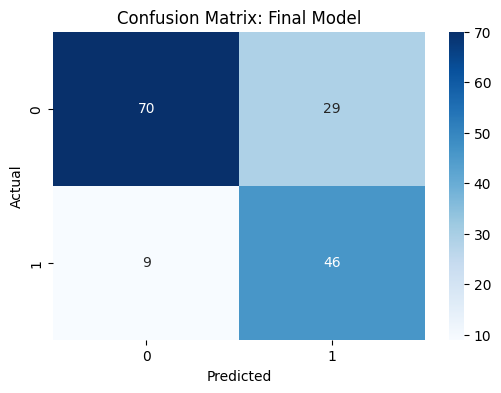

In [ ]:
## Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Final Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

This confusion matrix shows that the model is performing well for a medical case because it prioritizes safety; it successfully captured 84% of actual patients (46 out of 55), leaving only 9 False Negatives. While there are 29 False Positives where healthy people were flagged, this is an acceptable trade-off in disease diagnosis because missing a sick person is much more dangerous than double-checking a healthy one. Overall, the model is now much more reliable for clinical use because it focuses on minimizing missed diagnoses.

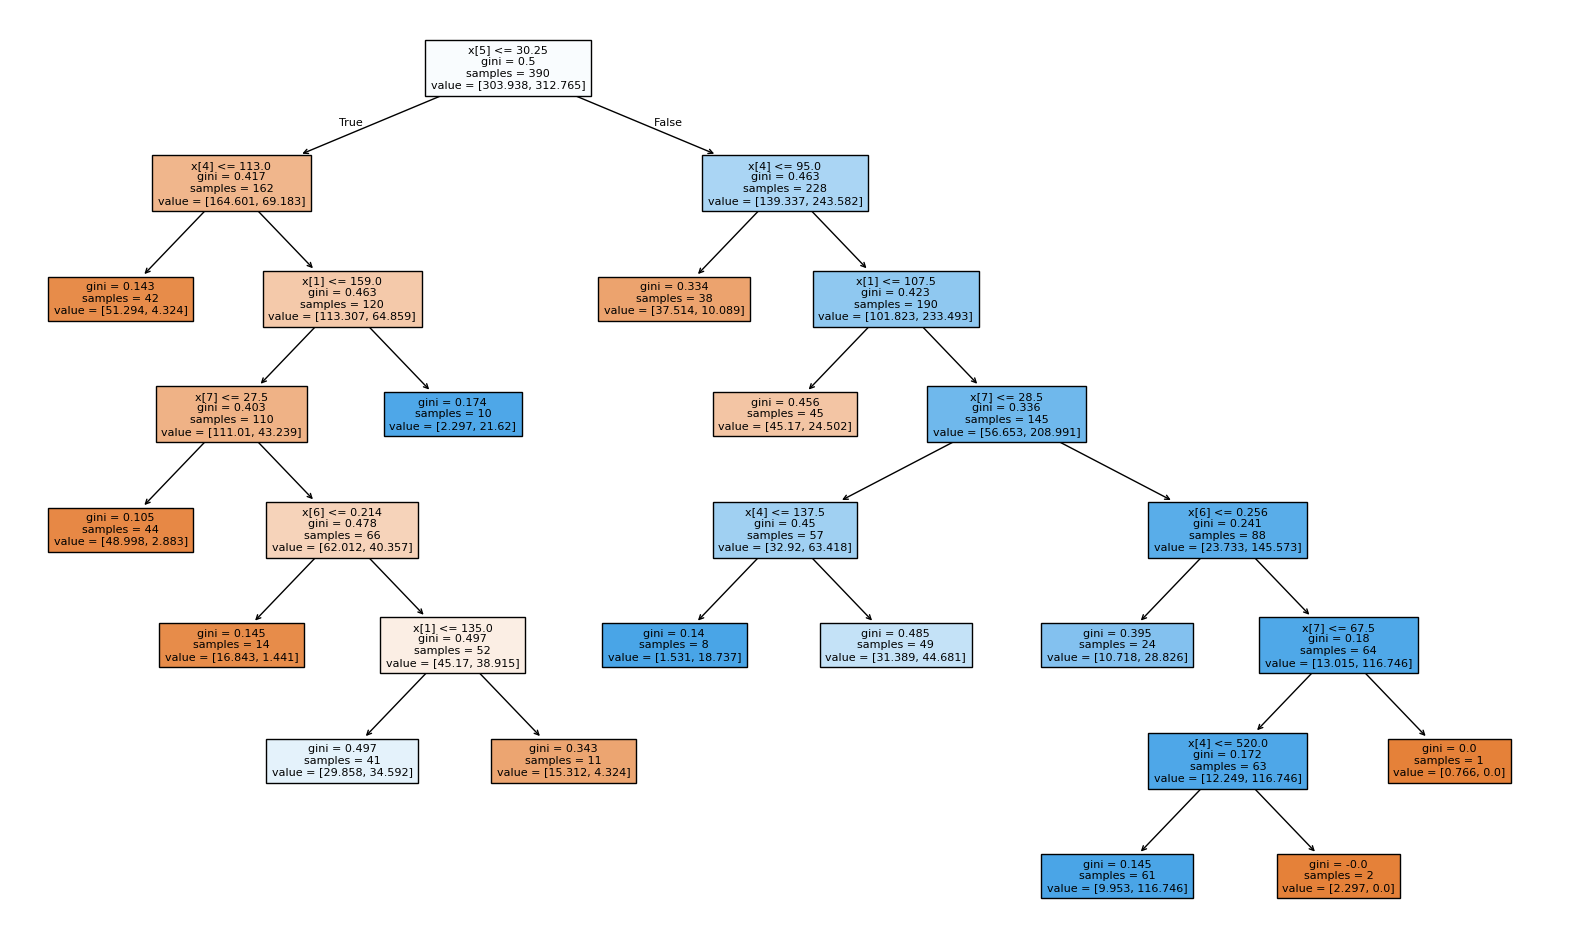

In [11]:
# Model evaluation by checking gini impurity
plt.figure(figsize=(20, 12))
tree.plot_tree(best_rf_model.estimators_[0],
               filled=True,
               fontsize=8)
plt.show()

**Gini Impurity vs Overfitting**

Looking at the tree, the Gini impurity on the right side (False path) is pretty much cleared out. If we keep splitting there, the model will just start memorizing 'noise,' which leads to overfitting. On the left side (True path), there's still a little bit of impurity left, but I think it's better to live with it. If we pushed for 100% purity by adding more levels, we'd likely hurt our precision and make the model 'too suspicious flagging way too many people as sick. Its all about finding that sweet spot where the model is smart but not over-sensitive.

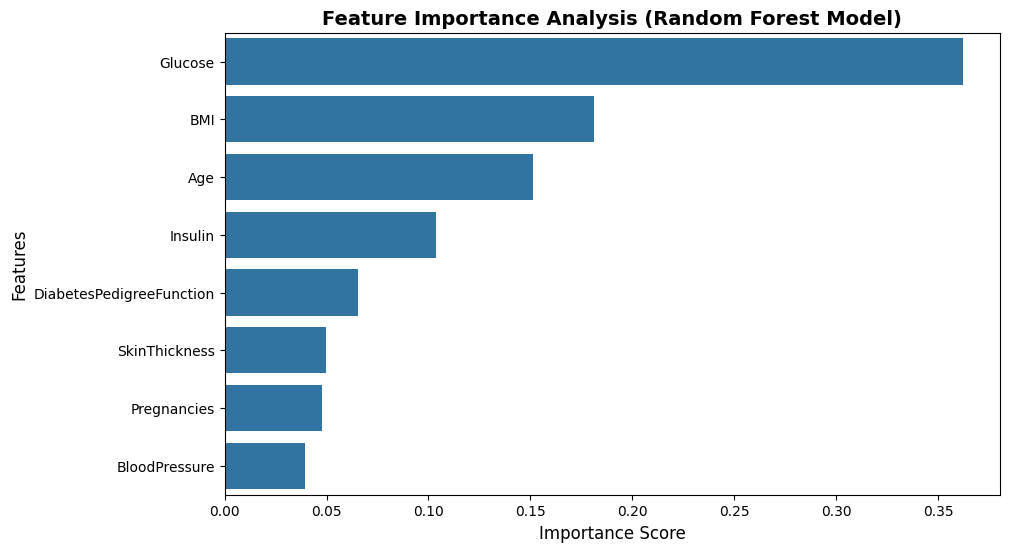

In [12]:
# Feature Importance
importances = best_rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance Analysis (Random Forest Model)',fontsize=14, fontweight='bold')
plt.xlabel('Importance Score',fontsize=12)
plt.ylabel('Features',fontsize=12)
plt.show()

**Glucose** and **BMI** are the dominant features in our model, contributing the most to accurate classification

## Model Comparison: Baseline vs. Optimized Performance

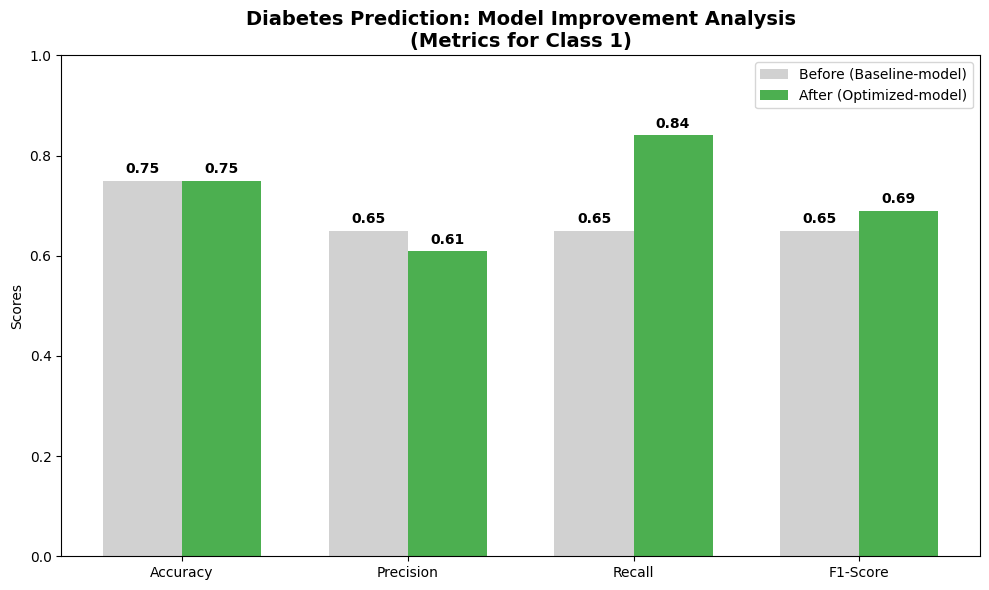

In [14]:
metrics = ['Accuracy', "Precision", 'Recall', 'F1-Score']
baseline_model_classficationreport_stats = [0.75, 0.65, 0.65 , 0.65]
optimized_model_classficationreport_stats = [0.75, 0.61, 0.84 , 0.69]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, baseline_model_classficationreport_stats, width, label='Before (Baseline-model)', color='#d1d1d1')
rects2 = ax.bar(x + width/2, optimized_model_classficationreport_stats, width, label='After (Optimized-model)', color='#4CAF50')

ax.set_ylabel('Scores')
ax.set_title('Diabetes Prediction: Model Improvement Analysis\n(Metrics for Class 1)', fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

This chart really highlights how much the model improved after tuning. The standout win here is the Recall, which jumped from 0.65 to 0.84, meaning we are now catching the vast majority of cases. Even though the Precision dropped slightly from 0.65 to 0.61, the fact that the F1-Score went up proves that this was a smart trade-off. Basically, the model is now way more reliable at spotting diabetes, which is exactly what we wanted for a medical project.

# **Summary**

In this project, I improved a diabetes prediction model by prioritizing medical safety over basic accuracy. Since the original model was missing too many cases, I used GridSearchCV to fine-tune it, which successfully boosted the Recall to 84%. This means the model is now much better at "catching" sick patients, even if it means a small drop in Precision. By analyzing Feature Importance, I confirmed that Glucose and BMI are the main factors driving these results.Ultimately, the model is now a much more reliable tool for doctors because it significantly reduces the chances of a patient going undiagnosed.